<a href="https://colab.research.google.com/github/Bpatnaik470/Bpatnaik470/blob/main/Capstone_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/adultcensusincome.csv')

# Display the first 5 rows
display(df.head())

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,Female,0,3900,40,United-States,<=50K


### Check for missing values (NaN) and '?' characters

In [8]:
import numpy as np

# Replace '?' with NaN
df = df.replace('?', np.nan)

# Check for null values after replacing '?'
print("Null values after handling '?' :\n", df.isnull().sum())

Null values after handling '?' :
 age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


### Check distribution of the target variable 'income'

In [9]:
# Get the distribution of the 'income' column
income_distribution = df['income'].value_counts()

print("Distribution of 'income' variable:\n", income_distribution)

# Calculate percentages for better understanding of balance
income_percentage = df['income'].value_counts(normalize=True) * 100

print("\nPercentage distribution of 'income' variable:\n", income_percentage)

# Determine if the dataset is balanced
if income_percentage.min() < 30:
    print("\nBased on the percentages, the dataset appears to be unbalanced.")
else:
    print("\nBased on the percentages, the dataset appears to be reasonably balanced.")

Distribution of 'income' variable:
 income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Percentage distribution of 'income' variable:
 income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64

Based on the percentages, the dataset appears to be unbalanced.


/tmp/ipykernel_50262/2073197665.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='income', palette='viridis')


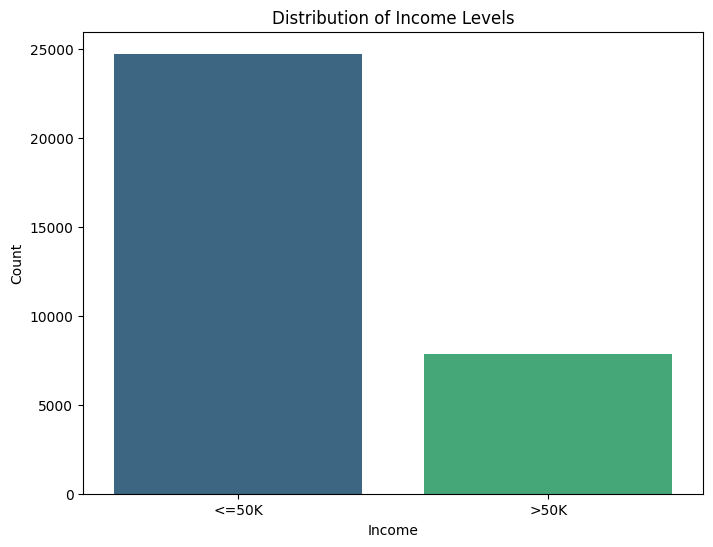

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='income', palette='viridis')
plt.title('Distribution of Income Levels')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

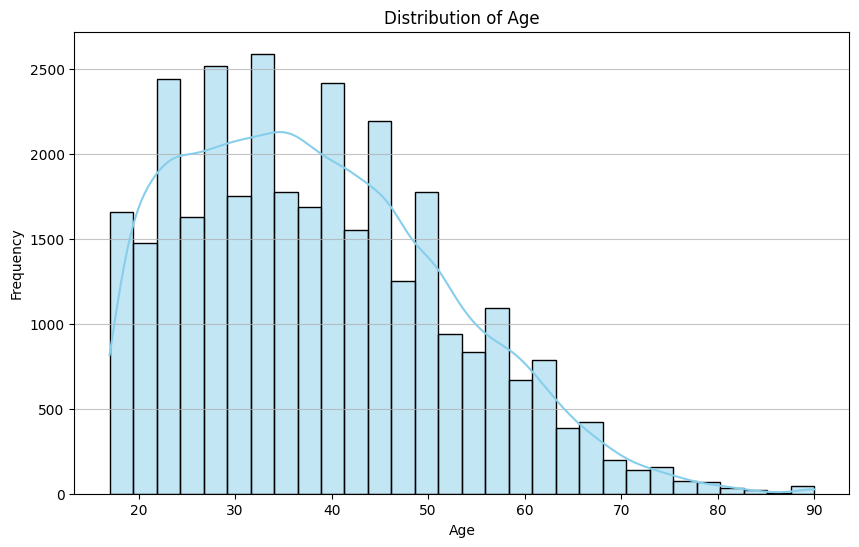

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['age'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

/tmp/ipykernel_50262/2959350682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='education.num', palette='viridis', order=df['education.num'].value_counts().index.sort_values())


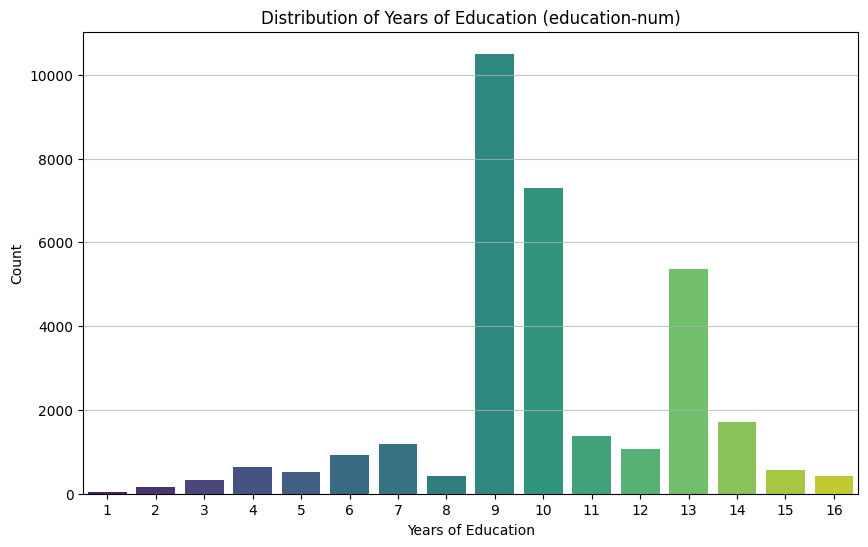

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='education.num', palette='viridis', order=df['education.num'].value_counts().index.sort_values())
plt.title('Distribution of Years of Education (education-num)')
plt.xlabel('Years of Education')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

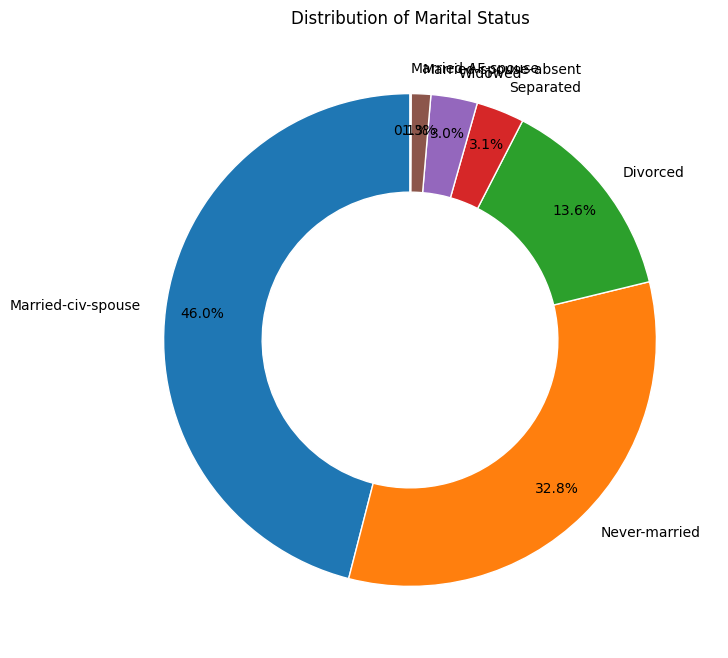

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
df['marital.status'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    wedgeprops=dict(width=0.4, edgecolor='w')
)
plt.title('Distribution of Marital Status')
plt.ylabel('') # Hide the default 'marital.status' label on the y-axis
plt.show()

### Income Distribution across Education Levels

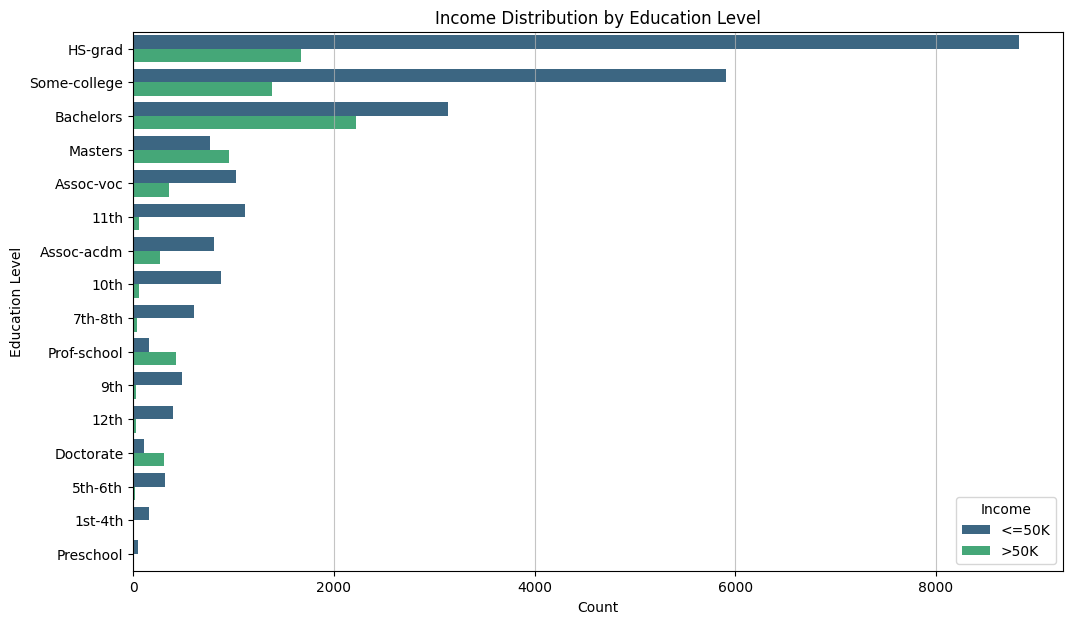

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='education', hue='income', palette='viridis', order=df['education'].value_counts().index)
plt.title('Income Distribution by Education Level')
plt.xlabel('Count')
plt.ylabel('Education Level')
plt.legend(title='Income')
plt.grid(axis='x', alpha=0.75)
plt.show()

### Income Distribution across Marital Status

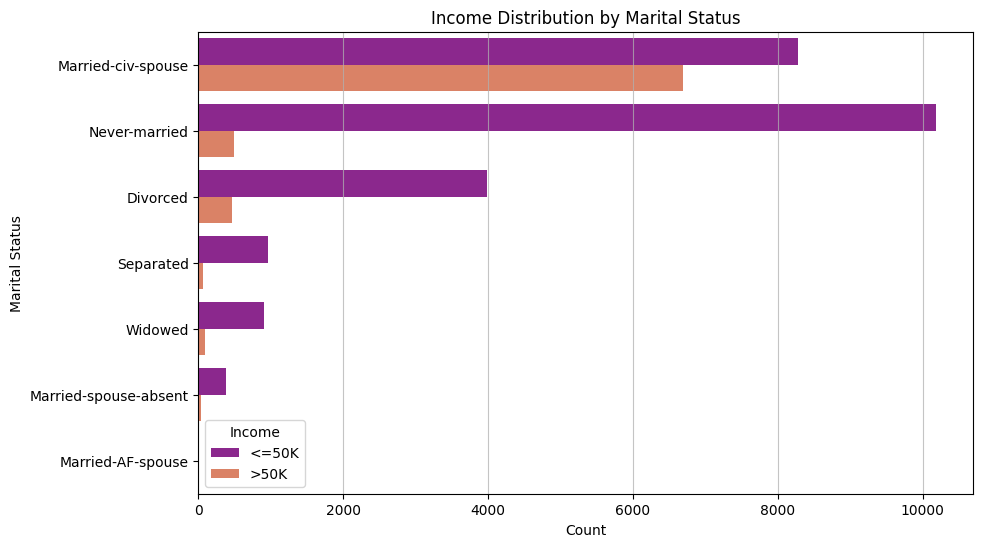

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='marital.status', hue='income', palette='plasma', order=df['marital.status'].value_counts().index)
plt.title('Income Distribution by Marital Status')
plt.xlabel('Count')
plt.ylabel('Marital Status')
plt.legend(title='Income')
plt.grid(axis='x', alpha=0.75)
plt.show()

### Income Distribution across Sex

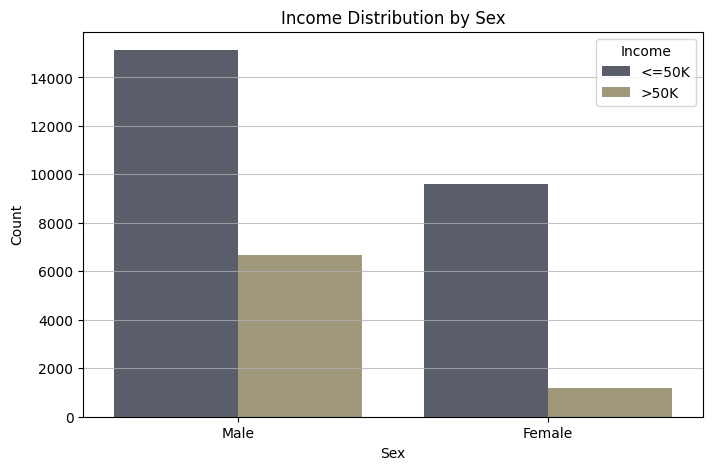

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sex', hue='income', palette='cividis', order=df['sex'].value_counts().index)
plt.title('Income Distribution by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Income')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Income Distribution across Age

/tmp/ipykernel_50262/4026707101.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Income')


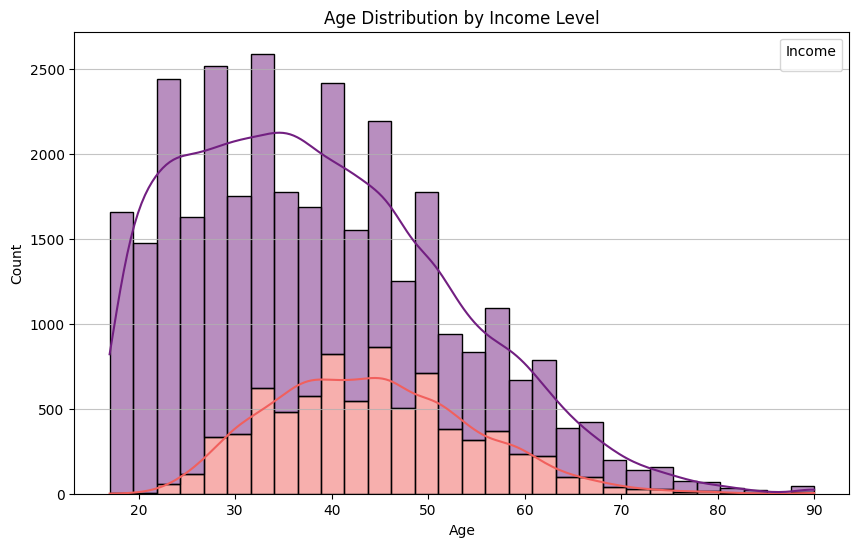

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='income', multiple='stack', kde=True, bins=30, palette='magma')
plt.title('Age Distribution by Income Level')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Income')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Correlation Heatmap and Highly Correlated Columns with Income

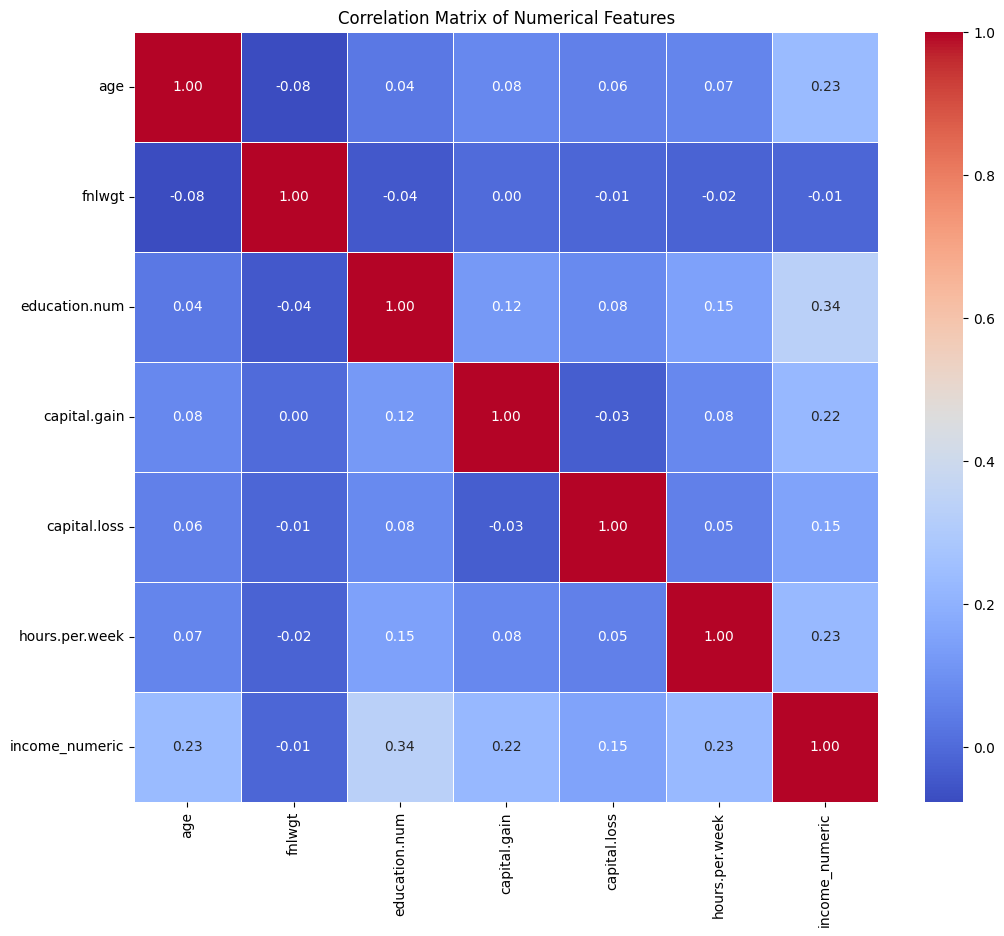


Columns highly correlated with Income (absolute correlation value > 0.3):
education.num    0.335154
Name: income_numeric, dtype: float64


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert 'income' to numerical for correlation calculation
# Assuming income '<=50K' is 0 and '>50K' is 1
df_corr = df.copy()
df_corr['income_numeric'] = df_corr['income'].apply(lambda x: 1 if x == '>50K' else 0)

# Select only numerical columns for correlation, including the new 'income_numeric'
numerical_cols = df_corr.select_dtypes(include=np.number).columns
correlation_matrix = df_corr[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print('\nColumns highly correlated with Income (absolute correlation value > 0.3):')
income_correlations = correlation_matrix['income_numeric'].sort_values(ascending=False)
high_correlation_threshold = 0.3 # You can adjust this threshold

# Filter for correlations above the threshold (absolute value)
high_correlations = income_correlations[(income_correlations.abs() > high_correlation_threshold) & (income_correlations.index != 'income_numeric')]

if not high_correlations.empty:
    print(high_correlations)
else:
    print('No columns found with absolute correlation greater than 0.3 with income.')

In [20]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

df_encoded = df.copy()

# Identify categorical columns (object type)
categorical_cols = df_encoded.select_dtypes(include='object').columns

print(f"Categorical columns to be encoded: {list(categorical_cols)}")

# Apply Label Encoding to each categorical column
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le # Store the encoder for inverse transformation if needed

print("\nDataFrame after Label Encoding:")
display(df_encoded.head())


Categorical columns to be encoded: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'sex', 'native.country', 'income']

DataFrame after Label Encoding:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,8,77053,11,9,6,14,1,0,0,4356,40,38,0
1,82,3,132870,11,9,6,3,1,0,0,4356,18,38,0
2,66,8,186061,15,10,6,14,4,0,0,4356,40,38,0
3,54,3,140359,5,4,0,6,4,0,0,3900,40,38,0
4,41,3,264663,15,10,5,9,3,0,0,3900,40,38,0


In [21]:
# Prepare independent variables (X) and dependent variable (Y)
X = df_encoded.drop('income', axis=1)
Y = df_encoded['income']

print("Shape of X (independent variables):")
print(X.shape)
print("\nShape of Y (dependent variable):")
print(Y.shape)

print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 rows of Y:")
display(Y.head())

Shape of X (independent variables):
(32561, 13)

Shape of Y (dependent variable):
(32561,)

First 5 rows of X:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country
0,90,8,77053,11,9,6,14,1,0,0,4356,40,38
1,82,3,132870,11,9,6,3,1,0,0,4356,18,38
2,66,8,186061,15,10,6,14,4,0,0,4356,40,38
3,54,3,140359,5,4,0,6,4,0,0,3900,40,38
4,41,3,264663,15,10,5,9,3,0,0,3900,40,38



First 5 rows of Y:


,income
0,0
1,0
2,0
3,0
4,0


### Feature Scaling using StandardScaler

In [22]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the independent variables (X)
X_scaled = scaler.fit_transform(X)

# Convert scaled array back to DataFrame for easier inspection (optional, but good for understanding)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("First 5 rows of scaled X:")
display(X_scaled_df.head())

print("\nShape of scaled X:")
print(X_scaled.shape)

First 5 rows of scaled X:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country
0,3.769612,2.922623,-1.067997,0.181332,-0.420060,2.249480,1.750756,-0.277805,-1.422331,-0.14592,10.593507,-0.035429,0.251378
1,3.183112,-0.237906,-0.539169,0.181332,-0.420060,2.249480,-0.790510,-0.277805,-1.422331,-0.14592,10.593507,-1.817204,0.251378
2,2.010110,2.922623,-0.035220,1.214869,-0.031360,2.249480,1.750756,1.589322,-1.422331,-0.14592,10.593507,-0.035429,0.251378
3,1.130359,-0.237906,-0.468215,-1.368974,-2.363558,-1.734058,-0.097437,1.589322,-1.422331,-0.14592,9.461864,-0.035429,0.251378
4,0.177296,-0.237906,0.709482,1.214869,-0.031360,1.585557,0.595635,0.966947,-1.422331,-0.14592,9.461864,-0.035429,0.251378



Shape of scaled X:
(32561, 13)


### Handling Imbalance using SMOTE

In [23]:
from imblearn.over_sampling import SMOTE
import pandas as pd # Ensure pandas is imported for DataFrame operations

# Before SMOTE, check the current class distribution of Y
print("Class distribution before SMOTE:\n", pd.Series(Y).value_counts())

# Initialize SMOTE
sm = SMOTE(random_state=42)

# Apply SMOTE to the scaled features (X_scaled) and target (Y)
X_resampled, Y_resampled = sm.fit_resample(X_scaled, Y)

print("\nClass distribution after SMOTE:\n", pd.Series(Y_resampled).value_counts())

print("\nShape of X after SMOTE:")
print(X_resampled.shape)
print("\nShape of Y after SMOTE:")
print(Y_resampled.shape)

print("\nFirst 5 rows of X_resampled:")
display(pd.DataFrame(X_resampled, columns=X.columns).head())
print("\nFirst 5 rows of Y_resampled:")
display(pd.Series(Y_resampled).head())

Class distribution before SMOTE:
 income
0    24720
1     7841
Name: count, dtype: int64

Class distribution after SMOTE:
 income
0    24720
1    24720
Name: count, dtype: int64

Shape of X after SMOTE:
(49440, 13)

Shape of Y after SMOTE:
(49440,)

First 5 rows of X_resampled:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country
0,3.769612,2.922623,-1.067997,0.181332,-0.420060,2.249480,1.750756,-0.277805,-1.422331,-0.14592,10.593507,-0.035429,0.251378
1,3.183112,-0.237906,-0.539169,0.181332,-0.420060,2.249480,-0.790510,-0.277805,-1.422331,-0.14592,10.593507,-1.817204,0.251378
2,2.010110,2.922623,-0.035220,1.214869,-0.031360,2.249480,1.750756,1.589322,-1.422331,-0.14592,10.593507,-0.035429,0.251378
3,1.130359,-0.237906,-0.468215,-1.368974,-2.363558,-1.734058,-0.097437,1.589322,-1.422331,-0.14592,9.461864,-0.035429,0.251378
4,0.177296,-0.237906,0.709482,1.214869,-0.031360,1.585557,0.595635,0.966947,-1.422331,-0.14592,9.461864,-0.035429,0.251378



First 5 rows of Y_resampled:


,income
0,0
1,0
2,0
3,0
4,0


In [24]:
from sklearn.model_selection import train_test_split

# Perform train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X_resampled, Y_resampled, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_train:", Y_train.shape)
print("Shape of Y_test:", Y_test.shape)


Shape of X_train: (39552, 13)
Shape of X_test: (9888, 13)
Shape of Y_train: (39552,)
Shape of Y_test: (9888,)


### Training Logistic Regression Model

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train Logistic Regression model
log_reg = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and handles L1/L2 penalties
log_reg.fit(X_train, Y_train)

# Predict on the test set
Y_pred_log_reg = log_reg.predict(X_test)

# Evaluate the model
print("Logistic Regression Accuracy:", accuracy_score(Y_test, Y_pred_log_reg))
print("\nLogistic Regression Classification Report:\n", classification_report(Y_test, Y_pred_log_reg))
print("\nLogistic Regression Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred_log_reg))

Logistic Regression Accuracy: 0.7694174757281553

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.77      0.77      4955
           1       0.77      0.77      0.77      4933

    accuracy                           0.77      9888
   macro avg       0.77      0.77      0.77      9888
weighted avg       0.77      0.77      0.77      9888


Logistic Regression Confusion Matrix:
 [[3799 1156]
 [1124 3809]]


### Training K-Nearest Neighbors (KNN) Classifier Model

In [26]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5) # You can tune n_neighbors
knn.fit(X_train, Y_train)

# Predict on the test set
Y_pred_knn = knn.predict(X_test)

# Evaluate the model
print("KNN Classifier Accuracy:", accuracy_score(Y_test, Y_pred_knn))
print("\nKNN Classifier Classification Report:\n", classification_report(Y_test, Y_pred_knn))
print("\nKNN Classifier Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred_knn))

KNN Classifier Accuracy: 0.8577063106796117

KNN Classifier Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.78      0.85      4955
           1       0.81      0.93      0.87      4933

    accuracy                           0.86      9888
   macro avg       0.87      0.86      0.86      9888
weighted avg       0.87      0.86      0.86      9888


KNN Classifier Confusion Matrix:
 [[3886 1069]
 [ 338 4595]]


### Training Support Vector Machine (SVM) Classifier

In [27]:
from sklearn.svm import SVC

# Initialize and train SVM Classifier
# Using 'linear' kernel for potentially faster training; 'rbf' is common but slower for large datasets
svm_model = SVC(random_state=42, kernel='linear')
svm_model.fit(X_train, Y_train)

# Predict on the test set
Y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
print("SVM Classifier Accuracy:", accuracy_score(Y_test, Y_pred_svm))
print("\nSVM Classifier Classification Report:\n", classification_report(Y_test, Y_pred_svm))
print("\nSVM Classifier Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred_svm))

SVM Classifier Accuracy: 0.7749797734627831

SVM Classifier Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.76      0.77      4955
           1       0.76      0.79      0.78      4933

    accuracy                           0.77      9888
   macro avg       0.78      0.78      0.77      9888
weighted avg       0.78      0.77      0.77      9888


SVM Classifier Confusion Matrix:
 [[3754 1201]
 [1024 3909]]


### Training Naive Bayes Classifier

In [30]:
from sklearn.naive_bayes import GaussianNB

# Initialize and train Gaussian Naive Bayes Classifier
nb_model = GaussianNB()
nb_model.fit(X_train, Y_train)

# Predict on the test set
Y_pred_nb = nb_model.predict(X_test)

# Evaluate the model
print("Naive Bayes Classifier Accuracy:", accuracy_score(Y_test, Y_pred_nb))
print("\nNaive Bayes Classifier Classification Report:\n", classification_report(Y_test, Y_pred_nb))
print("\nNaive Bayes Classifier Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred_nb))

Naive Bayes Classifier Accuracy: 0.6951860841423948

Naive Bayes Classifier Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.93      0.75      4955
           1       0.87      0.45      0.60      4933

    accuracy                           0.70      9888
   macro avg       0.75      0.69      0.68      9888
weighted avg       0.75      0.70      0.68      9888


Naive Bayes Classifier Confusion Matrix:
 [[4632  323]
 [2691 2242]]


### Training Decision Tree Classifier

In [28]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, Y_train)

# Predict on the test set
Y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
print("Decision Tree Classifier Accuracy:", accuracy_score(Y_test, Y_pred_dt))
print("\nDecision Tree Classifier Classification Report:\n", classification_report(Y_test, Y_pred_dt))
print("\nDecision Tree Classifier Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred_dt))

Decision Tree Classifier Accuracy: 0.8520428802588996

Decision Tree Classifier Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      4955
           1       0.85      0.86      0.85      4933

    accuracy                           0.85      9888
   macro avg       0.85      0.85      0.85      9888
weighted avg       0.85      0.85      0.85      9888


Decision Tree Classifier Confusion Matrix:
 [[4207  748]
 [ 715 4218]]


### Training Random Forest Classifier

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, Y_train)

# Predict on the test set
Y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Accuracy:", accuracy_score(Y_test, Y_pred_rf))
print("\nRandom Forest Classifier Classification Report:\n", classification_report(Y_test, Y_pred_rf))
print("\nRandom Forest Classifier Confusion Matrix:\n", confusion_matrix(Y_test, Y_pred_rf))

Random Forest Classifier Accuracy: 0.9002831715210357

Random Forest Classifier Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90      4955
           1       0.89      0.91      0.90      4933

    accuracy                           0.90      9888
   macro avg       0.90      0.90      0.90      9888
weighted avg       0.90      0.90      0.90      9888


Random Forest Classifier Confusion Matrix:
 [[4412  543]
 [ 443 4490]]
